In [2]:
print ("Hello")

Hello


# 🌸 Iris Flower Classification using K-Nearest Neighbors (KNN)

## Codveda Technologies - Machine Learning Internship

### Intern Information

**Name:** Muhammed Mumeenat

**Internship:** Machine Learning Internship

**Project:** K-Nearest Neighbors (KNN) Classification

---

## Project Objective

The objective of this project is to build a K-Nearest Neighbors (KNN) classification model capable of predicting the species of an iris flower based on its physical measurements.

The model will be evaluated using Accuracy, Precision, Recall, Confusion Matrix, and Classification Report.

# 1. Importing Required Libraries

The following libraries are imported for data manipulation, visualization, preprocessing, model training, and evaluation.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# 2. Loading the Dataset

The Iris dataset is loaded into a Pandas DataFrame.

It contains measurements of iris flowers, including sepal length, sepal width, petal length, and petal width.

The target variable is the flower species.

In [4]:
df = pd.read_csv("../datasets/iris.csv")

# 3. Exploring the Dataset

Before training a machine learning model, it is important to understand the structure and characteristics of the dataset.

The following commands display the first few records, dataset dimensions, data types, and statistical summary.

In [5]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
df.shape

(150, 5)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [8]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Observation

The Iris dataset contains measurements of iris flowers and includes both numerical features and a categorical target variable (species).

The dataset appears complete and suitable for classification.

# 4. Checking for Missing Values

Missing values can reduce the performance of machine learning models.

The following command checks whether the dataset contains any missing values.

In [9]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

### Observation

The dataset contains no missing values, so no data cleaning or imputation is required before training the classification model.

# 5. Understanding the Target Variable

The target variable represents the flower species that the model will predict.

Before training the model, it is useful to examine the unique classes present in the dataset.

In [10]:
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

# 6. Feature Selection

Machine learning models require input features (X) and a target variable (y).

The input features consist of the flower measurements, while the target variable is the flower species.

The model will learn the relationship between these measurements and the corresponding species.

In [11]:
X = df.drop("species", axis=1)

y = df["species"]

In [12]:
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [13]:
y.head()

0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: str

### Observation

The input features (X) contain the numerical measurements of the flowers.

The target variable (y) contains the species labels that the model will predict.

# 7. Splitting the Dataset

The dataset is divided into training and testing sets.

The training set is used to teach the model, while the testing set is used to evaluate how well the trained model performs on unseen data.

In this project, 80% of the data is used for training and 20% for testing.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [16]:
print(y_train.shape)
print(y_test.shape)

(120,)
(30,)


# 8. Feature Scaling

K-Nearest Neighbors (KNN) is a distance-based machine learning algorithm.

Since different features may have different scales, feature scaling is performed to ensure that all features contribute equally when calculating distances.

StandardScaler is used to transform the features so that they have a mean of 0 and a standard deviation of 1.

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [18]:
X_train[:5]

array([[-1.47393679,  1.22037928, -1.5639872 , -1.30948358],
       [-0.13307079,  3.02001693, -1.27728011, -1.04292204],
       [ 1.08589829,  0.09560575,  0.38562104,  0.28988568],
       [-1.23014297,  0.77046987, -1.21993869, -1.30948358],
       [-1.7177306 ,  0.32056046, -1.39196294, -1.30948358]])

### Observation

The training and testing data have been standardized using StandardScaler.

Feature scaling is essential for KNN because the algorithm calculates distances between data points. Without scaling, features with larger values could dominate the distance calculations and negatively affect the model's performance.

# 9. Building the K-Nearest Neighbors Model

The K-Nearest Neighbors classifier is initialized with **k = 5**, meaning the model considers the five nearest neighbors when classifying a new sample.

The model is then trained using the scaled training dataset.

In [19]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['setosa','versicolor','virginica']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


# 10. Making Predictions

After training the KNN classifier, the model is used to predict the species of the flowers in the testing dataset.

These predictions will be compared with the actual labels to evaluate the model's performance.

In [20]:
y_pred = knn.predict(X_test)

In [21]:
print(y_pred)

['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor' 'virginica' 'setosa'
 'setosa' 'setosa' 'setosa' 'versicolor' 'virginica' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'setosa' 'virginica'
 'virginica' 'virginica' 'virginica' 'virginica' 'setosa' 'setosa']


# 11. Evaluating the Model

The accuracy score measures the proportion of correctly classified samples.

A higher accuracy indicates better classification performance.

In [22]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


# 12. Confusion Matrix

A confusion matrix summarizes the classification results by comparing the actual class labels with the predicted class labels.

It helps identify the number of correct and incorrect predictions made by the model.

In [23]:
cm=confusion_matrix(y_test, y_pred)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


# 13. Classification Report

The classification report provides Precision, Recall, F1-score, and Support for each class.

These metrics offer a more detailed evaluation of the classifier than accuracy alone.

In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# 14. Comparing Different Values of K

The performance of the K-Nearest Neighbors algorithm depends on the value of **K**, which represents the number of nearest neighbors considered during classification.

Different values of K are tested to determine which one produces the highest classification accuracy.

In [25]:
k_values = [1, 3, 5, 7, 9]

accuracy_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    score = accuracy_score(y_test, predictions)

    accuracy_scores.append(score)

print(accuracy_scores)

[1.0, 1.0, 1.0, 1.0, 1.0]


# 15. Accuracy Comparison

The classification accuracy obtained for different values of K is visualized using a line graph.

This helps identify the optimal value of K for the Iris classification problem.

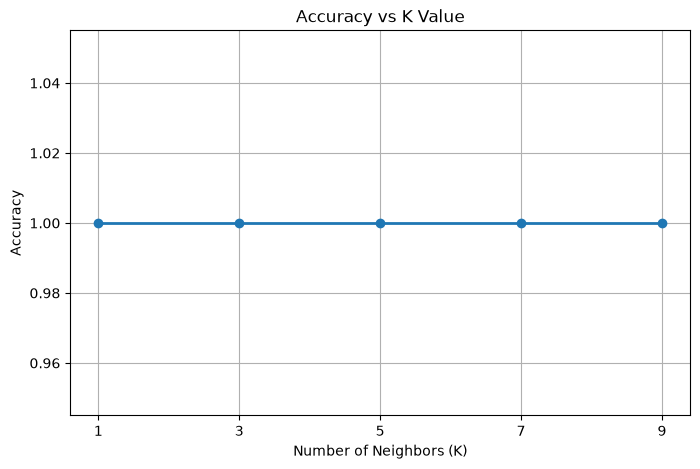

In [30]:
plt.figure(figsize=(8,5))

plt.plot(k_values, accuracy_scores, marker='o', linewidth=2)

plt.xticks(k_values)

plt.title("Accuracy vs K Value")

plt.xlabel("Number of Neighbors (K)")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

In [28]:
best_k=k_values[accuracy_scores.index(max(accuracy_scores))]
print("Best K Values:", best_k)
print("Best Accuracy:", max(accuracy_scores))


Best K Values: 1
Best Accuracy: 1.0


# 16. Conclusion

In this project, a K-Nearest Neighbors (KNN) classifier was successfully developed to classify Iris flower species based on their physical measurements.

The dataset was preprocessed, scaled using StandardScaler, and divided into training and testing datasets. The trained model achieved high classification accuracy, demonstrating the effectiveness of KNN for this classification task.

Different values of K were also evaluated to determine the optimal number of neighbors for the model.

Overall, the project illustrates the complete workflow of building and evaluating a supervised machine learning classification model using Python and Scikit-learn.

# Key Learning Outcomes

Through this project, the following machine learning concepts were learned:

- Data exploration using Pandas
- Feature selection
- Training and testing dataset split
- Feature scaling using StandardScaler
- Building a K-Nearest Neighbors classifier
- Making predictions on unseen data
- Evaluating model performance using Accuracy
- Understanding the Confusion Matrix
- Interpreting the Classification Report
- Comparing different values of K to identify the optimal model